   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  

RESULTADOS

R2: 0.926380103264486


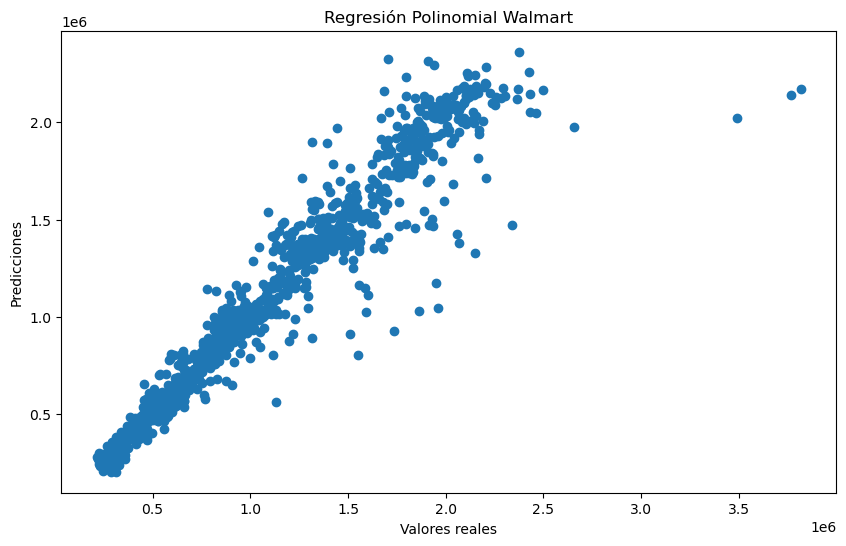

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score



dataset = pd.read_csv("datasets/Walmart.csv")

print(dataset.head())



dataset = pd.get_dummies(dataset,columns=['Store'],drop_first=True)



X = dataset.drop(columns=['Weekly_Sales', 'Date'])



y = dataset['Weekly_Sales']


X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(X,y,test_size=0.2,random_state=42)


normalizador = StandardScaler()

X_entrenamiento_normalizado = normalizador.fit_transform(X_entrenamiento)

X_prueba_normalizado = normalizador.transform( X_prueba)


polinomio = PolynomialFeatures(degree=2)

X_entrenamiento_polinomial = polinomio.fit_transform(X_entrenamiento_normalizado)

X_prueba_polinomial = polinomio.transform(X_prueba_normalizado)



modelo = LinearRegression()

modelo.fit(X_entrenamiento_polinomial,y_entrenamiento)


predicciones = modelo.predict(X_prueba_polinomial)



r2 = r2_score(y_prueba,predicciones)


print("\nRESULTADOS\n")


print("R2:", r2)


plt.figure(figsize=(10,6))

plt.scatter(y_prueba,predicciones)

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")

plt.title("Regresión Polinomial Walmart")

plt.show()

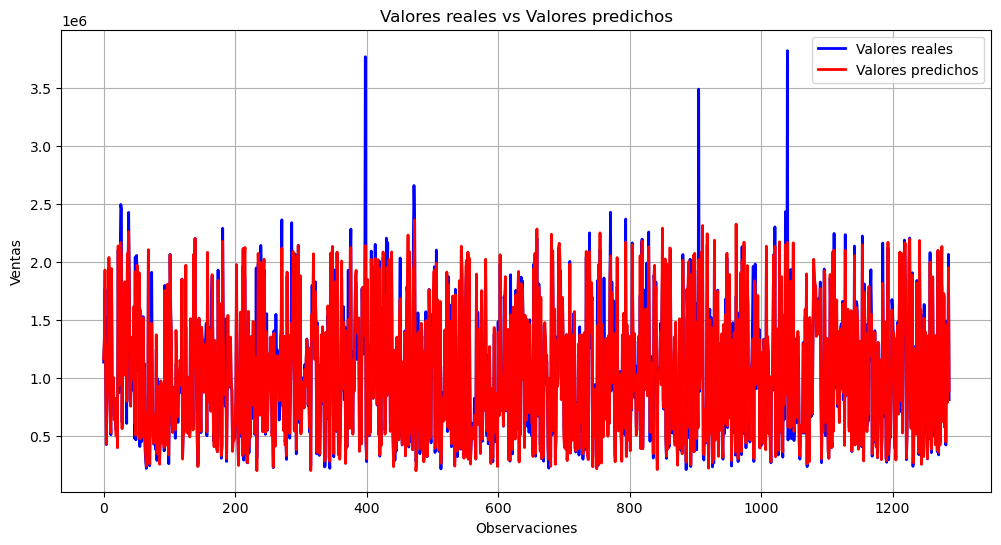

In [2]:

plt.figure(figsize=(12,6))

# Valores reales
plt.plot(y_prueba.values,color='blue',label='Valores reales',linewidth=2)

# Valores predichos
plt.plot( predicciones,color='red',label='Valores predichos',linewidth=2)

# Etiquetas
plt.xlabel("Observaciones")
plt.ylabel("Ventas")

# Título
plt.title("Valores reales vs Valores predichos")

# Leyenda
plt.legend()

# Cuadrícula
plt.grid(True)

# Mostrar gráfica
plt.show()

In [3]:

nueva_semana = pd.DataFrame({

    'Temperature': [25],
    'Fuel_Price': [3.2],
    'CPI': [220],
    'Unemployment': [7],
    'Holiday_Flag': [1],

    # VARIABLES ONE HOT DE STORE
    'Store_2': [0],
    'Store_3': [0],
    'Store_4': [0],
    'Store_5': [1],

    # El resto de tiendas en 0
})


nueva_semana = nueva_semana.reindex(columns=X.columns,fill_value=0)


nueva_semana_normalizada = normalizador.transform(nueva_semana)


nueva_semana_polinomial = polinomio.transform(nueva_semana_normalizada)


prediccion = modelo.predict(nueva_semana_polinomial)


print("\nVENTAS PREDICHAS:")

print(prediccion[0])


VENTAS PREDICHAS:
434529.42232884094


## ACTIVIDAD PARA CLASE

- Incluir todas métricas de avaluación de modelo - OK
- Gráfica con diferente color en predicción y valor real ( grafica de barras ) - OK
- Analizar el orden en que se normalizan los datos
-- Para este punto el objeto StandardScaler, realiza primeramente Calcula la media de la variable y se la resta a cada dato, posteriormente divide el resultado anterior entre la desviación estándar. El método fit_transform entrena el modelo, y con cada iteracion interna modifica los datos internos con los que opera hasta obtener los datos normalizados. Este método no debería realizarse con los datos de prueba.
- verificar la normalización de día feriado
-- Internamente, al ser datos binarizados entre 1 y 0 y los de store_* en booleano, se tomar como valores 1 y 0 y ocn base a ellos se hace la normalización.
- Realizar 2 predicciones - OK
- Subir R2 - OK
 

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  
Despues de aplicar el one-hot
         Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0  05-02-2010    1643690.90         False        42.31       2.572   
1  12-02-2010    1641957.44          True        38.51       2.548   
2  19-02-2010    1611968.17         False        39.93       2.514   
3  26-02-2010    1409727.59         False      

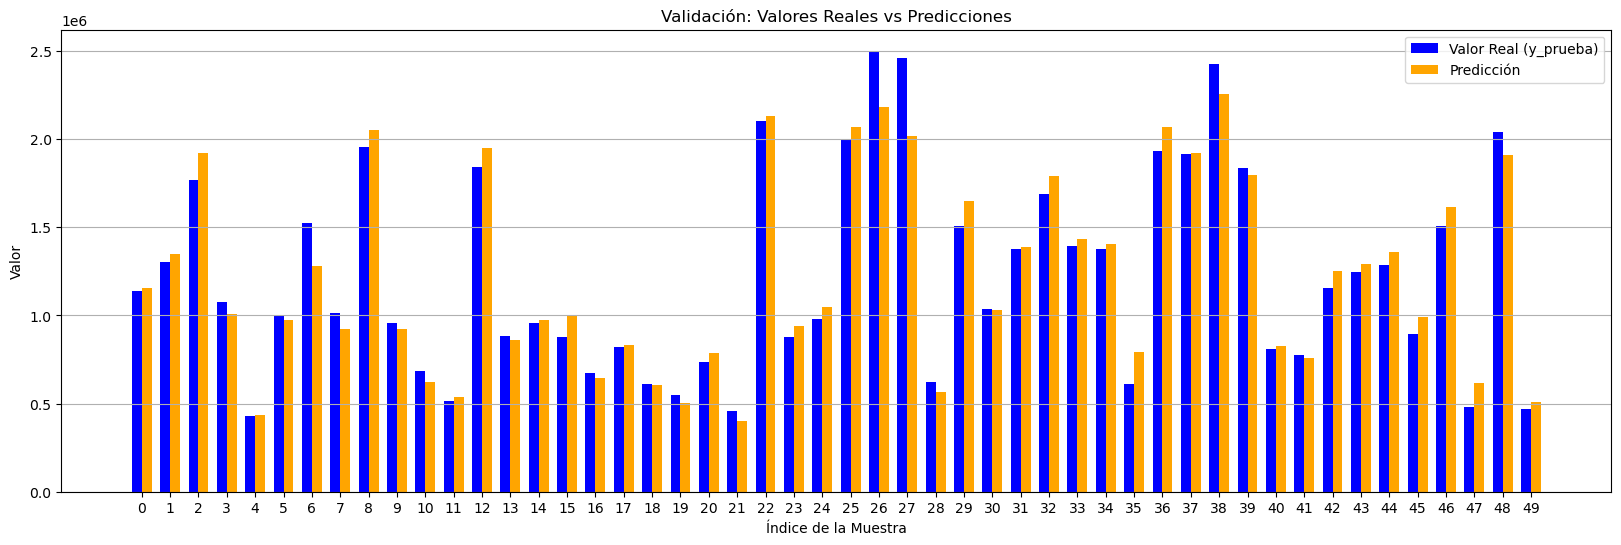

In [4]:
# Importando las librerias necesarias para la ejecución de este script

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Leyendo el dataset desde el filesystem
dataset = pd.read_csv("datasets/Walmart.csv")

# Mostrando los primeros 5 registros del dataset
print(dataset.head(5))

# Realizando el one-hot-label para mapear el número de tienda
dataset = pd.get_dummies(dataset,columns=['Store'] )

# Mapeando el campo binario 'Holiday_Flag' a valores binarios
dataset['Holiday_Flag'] = dataset['Holiday_Flag'].map({
    1: True,
    0: False
})

# Mostrando los primeros 5 registros del dataset después de realizar los mapeos correspondientes
print('Despues de aplicar el one-hot')
print(dataset.head(5))

# Generamos los conjuntos de datos para X e Y
X = dataset.drop(columns=['Weekly_Sales', 'Date'])
y = dataset['Weekly_Sales']


X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(X,y,test_size=0.1,random_state=42)

# Aplicando la normalización de datos a través del obj StandardScaler
normalizador = StandardScaler()
X_entrenamiento_normalizado = normalizador.fit_transform( X_entrenamiento )
X_prueba_normalizado = normalizador.transform( X_prueba )

print("W")
print(X_prueba_normalizado)

# Realizando operaciones polinominales
polinomio = PolynomialFeatures(degree=2)
X_entrenamiento_polinomial = polinomio.fit_transform(X_entrenamiento_normalizado)
X_prueba_polinomial = polinomio.transform(X_prueba_normalizado)

# Realizando regresión lineal a los datos entrenando el modelo y realizando la prediccion con el conjunto de prueba
modelo = LinearRegression()
modelo.fit(X_entrenamiento_polinomial,y_entrenamiento)
predicciones = modelo.predict(X_prueba_polinomial)



# Obteniendo las métricas del modelo
mse = mean_squared_error(y_prueba,predicciones)
mae = mean_absolute_error(y_prueba,predicciones)
rmse = np.sqrt(mse)
r2 = r2_score(y_prueba,predicciones)

# Imprimiendo las métricas del modelo
print("\n============================")
print("MÉTRICAS DEL MODELO")
print("============================")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

######################################################################################################################
#           REALIZANDO LA GRÁFICA PARA COMPARAR VALORES REALES VS LOS PREDICHOS POR EL ALGORITMO                     #
######################################################################################################################

# No podemos gráficar todos los valores, serían muchos datos aunque usemos el conjunto de valores predichos como metrica.
# Por lo que tomaremos un grupo de 50.
# Configuramos el tamaño de la barra
n_muestras = 50
pasos = np.arange(n_muestras) 
ancho_barra = 0.35            

# Se obtienen los primeros 50 valores de cada conjunto
y_real_muestra = np.array(y_prueba)[:n_muestras]
pred_muestra = np.array(predicciones)[:n_muestras]

# Definimos el tamaño de la gráfica
plt.figure(figsize=(20, 6))

# Graficamos ambos valores obtenidos de 50 por conjunto
plt.bar(pasos - ancho_barra/2, y_real_muestra, width=ancho_barra, color='blue', label='Valor Real (y_prueba)')
plt.bar(pasos + ancho_barra/2, pred_muestra,  width=ancho_barra, color='orange', label='Predicción')

# Dejamos bonita la grafica
plt.xlabel('Índice de la Muestra')
plt.ylabel('Valor')
plt.title('Validación: Valores Reales vs Predicciones')
plt.xticks(pasos) 
plt.legend()  
plt.grid(axis='y', linestyle='-', alpha=1) 
plt.show()

In [5]:
# Predicción 1
nueva_semana = pd.DataFrame({
    'Temperature': [25],
    'Fuel_Price': [3.2],
    'CPI': [220],
    'Unemployment': [7],
    'Holiday_Flag': [1],
    'Store_5': [1]
})


nueva_semana = nueva_semana.reindex(columns=X.columns,fill_value=0)
nueva_semana_normalizada = normalizador.transform(nueva_semana)
nueva_semana_polinomial = polinomio.transform(nueva_semana_normalizada)
prediccion = modelo.predict(nueva_semana_polinomial)
print("\nVENTAS PREDICHAS:")
print(prediccion[0])


VENTAS PREDICHAS:
471191.8210418811


In [6]:
# Predicción 2
nueva_semana = pd.DataFrame({
    'Temperature': [40],
    'Fuel_Price': [2.0],
    'CPI': [110],
    'Unemployment': [20],
    'Holiday_Flag': [0],
    'Store_1': [1]
})


nueva_semana = nueva_semana.reindex(columns=X.columns,fill_value=0)
nueva_semana_normalizada = normalizador.transform(nueva_semana)
nueva_semana_polinomial = polinomio.transform(nueva_semana_normalizada)
prediccion = modelo.predict(nueva_semana_polinomial)
print("\nVENTAS PREDICHAS:")
print(prediccion[0])


VENTAS PREDICHAS:
25497302.777159385
